In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
broadband = pd.read_csv("../Data/filled_broadband.csv")
prepaid = pd.read_csv("../Data/filled_prepaid.csv")
postpaid = pd.read_csv("../Data/filled_postpaid.csv")

age

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Age Distributions", fontsize=25, fontweight="bold")

axs[0].set_title("Broadband", pad=20, fontsize=20)
broadband["age"].plot.hist(ax=axs[0], bins=broadband["age"].nunique(), alpha=0.5)

axs[1].set_title("Prepaid", pad=20, fontsize=20)
prepaid["age"].plot.hist(ax=axs[1], bins=prepaid["age"].nunique(), alpha=0.5)

axs[2].set_title("Postpaid", pad=20, fontsize=20)
postpaid["age"].plot.hist(ax=axs[2], bins=postpaid["age"].nunique(), alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

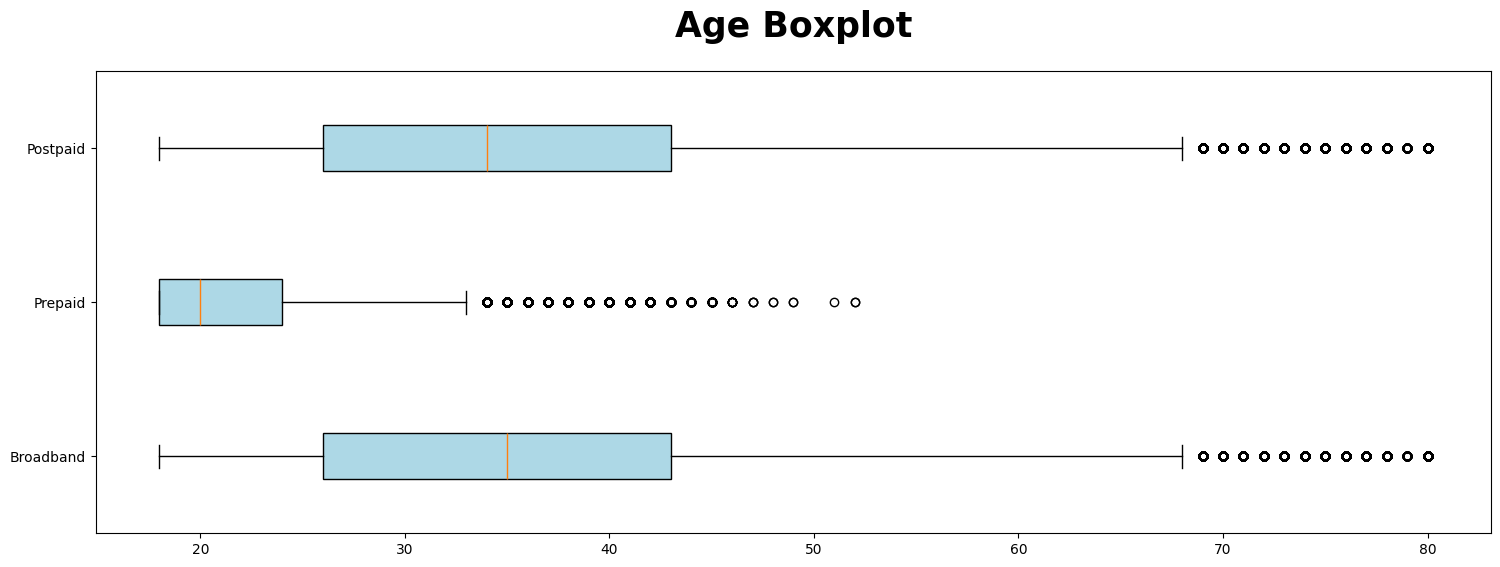

In [7]:
plt.figure(figsize=(18, 6))
plt.title("Age Boxplot", fontsize=25, fontweight="bold", pad=25)
plt.boxplot([broadband["age"], prepaid["age"], postpaid["age"]], 
            tick_labels=["Broadband", "Prepaid", "Postpaid"], 
            vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue"))
plt.show()

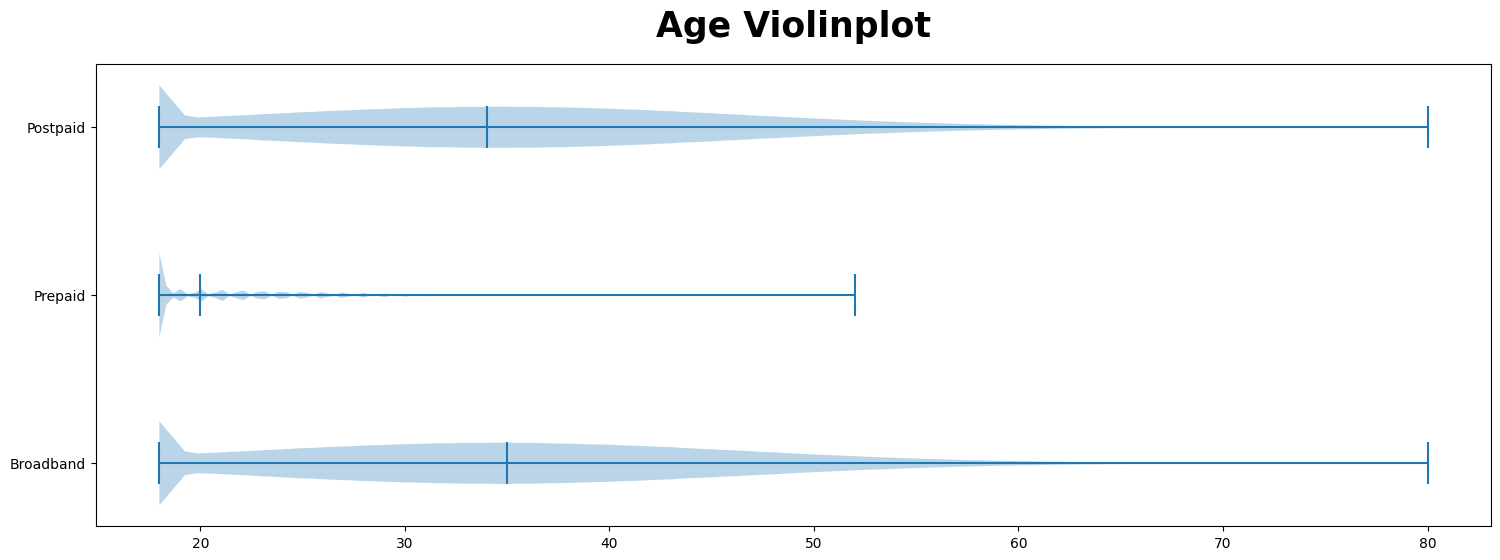

In [8]:
plt.figure(figsize=(18, 6))
plt.title("Age Violinplot", fontsize=25, fontweight="bold", pad=20)
plt.violinplot([broadband["age"], prepaid["age"], postpaid["age"]], 
               showmeans=False, showmedians=True, vert=False)
plt.yticks([1, 2, 3], ["Broadband", "Prepaid", "Postpaid"])
plt.show()

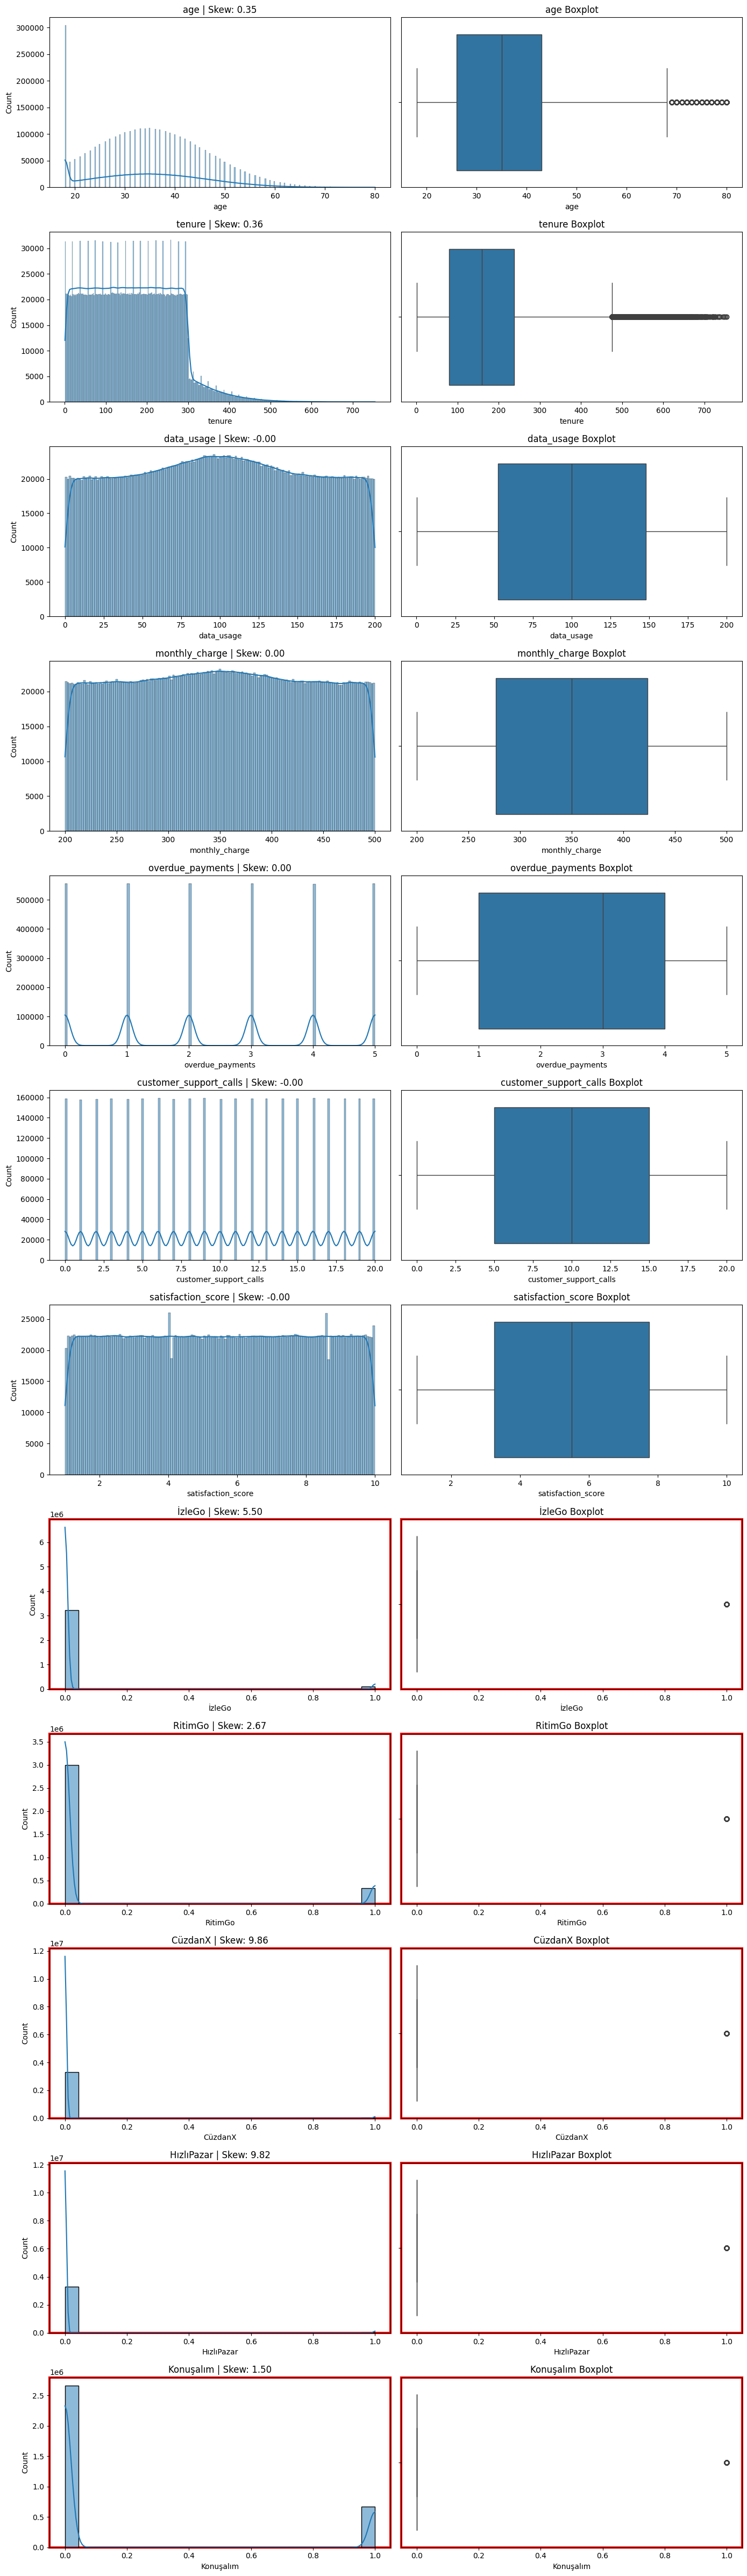

Çarpık Değişkenler (mutlak çarpıklık > 0.75):


CüzdanX       9.864814
HızlıPazar    9.817388
İzleGo        5.498179
RitimGo       2.669144
Konuşalım     1.497871
dtype: float64

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

def detect_skewed_variables(df, threshold=0.5, columns=None):
    """
    Çarpık değişkenleri tespit etmek için görselleştirme yapar.

    Parametreler:
    df (pd.DataFrame): İncelenecek veri çerçevesi
    threshold (float): Çarpıklık için eşik değeri (varsayılan: 0.5)
    columns (list): Analiz edilecek spesifik kolonlar (varsayılan: tüm sayısal kolonlar)
    """
    # Sayısal kolonları seç
    if columns is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        numeric_cols = columns
    
    # Çarpıklık değerlerini hesapla
    skewness = df[numeric_cols].apply(lambda x: skew(x.dropna()))
    
    # Görselleştirme
    plt.figure(figsize=(14, len(numeric_cols)*4))
    gs = plt.GridSpec(len(numeric_cols), 2)
    
    for i, col in enumerate(numeric_cols):
        ax1 = plt.subplot(gs[i, 0])
        sns.histplot(df[col], kde=True, ax=ax1)
        ax1.set_title(f'{col} | Skew: {skewness[col]:.2f}', fontsize=12)
        
        ax2 = plt.subplot(gs[i, 1])
        sns.boxplot(x=df[col], ax=ax2)
        ax2.set_title(f'{col} Boxplot', fontsize=12)
        
        # Çarpıklık vurgulama
        if abs(skewness[col]) > threshold:
            for ax in [ax1, ax2]:
                ax.patch.set_edgecolor('red')
                ax.patch.set_linewidth(3)

    plt.tight_layout()
    plt.show()
    
    # Çarpık değişkenleri raporla
    skewed_columns = skewness[abs(skewness) > threshold].sort_values(ascending=False)
    print("Çarpık Değişkenler (mutlak çarpıklık > {}):".format(threshold))
    return skewed_columns

# Örnek Kullanım:
# from sklearn.datasets import load_boston
# data = load_boston()
detect_skewed_variables(broadband, threshold=0.75)